In [24]:
import csv
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True

In [25]:
data_dir = Path(".")   # change this if needed
csv_files = sorted(data_dir.glob("SIG*.csv"))

print(f"Found {len(csv_files)} CSV files:")
for f in csv_files:
    print(f.name)

Found 17 CSV files:
SIG0029.csv
SIG0030.csv
SIG0031.csv
SIG0032.csv
SIG0033.csv
SIG0034.csv
SIG0035.csv
SIG0036.csv
SIG0037.csv
SIG0038.csv
SIG0039.csv
SIG0040.csv
SIG0041.csv
SIG0042.csv
SIG0043.csv
SIG0044.csv
SIG0045.csv


In [26]:
def to_float(x):
    x = x.strip()
    if x == "":
        return np.nan
    return float(x)

def parse_edm_csv(path):
    with open(path, "r", encoding="utf-8-sig", newline="") as f:
        rows = list(csv.reader(f))
    
    rows = [[cell.strip() for cell in row] for row in rows]

    header_idx = None
    for i, row in enumerate(rows):
        if len(row) >= 11 and row[0].startswith("X(s)") and row[3].startswith("X(Hz)") and row[6].startswith("X(Hz)"):
            header_idx = i
            break

    if header_idx is None:
        raise ValueError(f"Could not find numeric header row in {path.name}")

    data_rows = rows[header_idx + 1:]
    data_rows = [row + [""] * (11 - len(row)) if len(row) < 11 else row for row in data_rows]

    time = np.array([to_float(r[0]) for r in data_rows])
    force = np.array([to_float(r[1]) for r in data_rows])
    accel = np.array([to_float(r[2]) for r in data_rows])

    freq_aps = np.array([to_float(r[3]) for r in data_rows])
    aps_force = np.array([to_float(r[4]) for r in data_rows])
    aps_accel = np.array([to_float(r[5]) for r in data_rows])

    freq_frf = np.array([to_float(r[6]) for r in data_rows])
    frf_real = np.array([to_float(r[7]) for r in data_rows])
    frf_imag = np.array([to_float(r[8]) for r in data_rows])

    freq_coh = np.array([to_float(r[9]) for r in data_rows])
    coh = np.array([to_float(r[10]) for r in data_rows])

    frf_mag = np.sqrt(frf_real**2 + frf_imag**2)
    frf_phase_deg = np.degrees(np.arctan2(frf_imag, frf_real))

    m = re.search(r"SIG(\d+)", path.stem, re.IGNORECASE)
    sig_num = int(m.group(1)) if m else None

    return {
        "file": path.name,
        "sig_num": sig_num,
        "time": time,
        "force": force,
        "accel": accel,
        "freq_frf": freq_frf,
        "frf_real": frf_real,
        "frf_imag": frf_imag,
        "frf_mag": frf_mag,
        "frf_phase_deg": frf_phase_deg,
        "coherence": coh
    }

In [27]:
data = [parse_edm_csv(f) for f in csv_files]
data = sorted(data, key=lambda d: d["sig_num"])

print(f"Loaded {len(data)} files.")
print("First file:", data[0]["file"])
print("Last file:", data[-1]["file"])

Loaded 17 files.
First file: SIG0029.csv
Last file: SIG0045.csv


In [28]:
FREQ_MIN = 0
FREQ_MAX = 1800

def restrict_band(freq, *arrays, fmin=FREQ_MIN, fmax=FREQ_MAX):
    mask = np.isfinite(freq) & (freq >= fmin) & (freq <= fmax)
    out = [freq[mask]]
    for arr in arrays:
        out.append(arr[mask])
    return out

def hz_to_samples(freq, min_peak_distance_hz=80):
    df = np.median(np.diff(freq))
    return max(1, int(round(min_peak_distance_hz / df)))

### 1a

In [69]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.size": 26,        # base font
    "axes.titlesize": 26,
    "axes.labelsize": 26,
    "xtick.labelsize": 26,
    "ytick.labelsize": 26,
    "legend.fontsize": 26
})

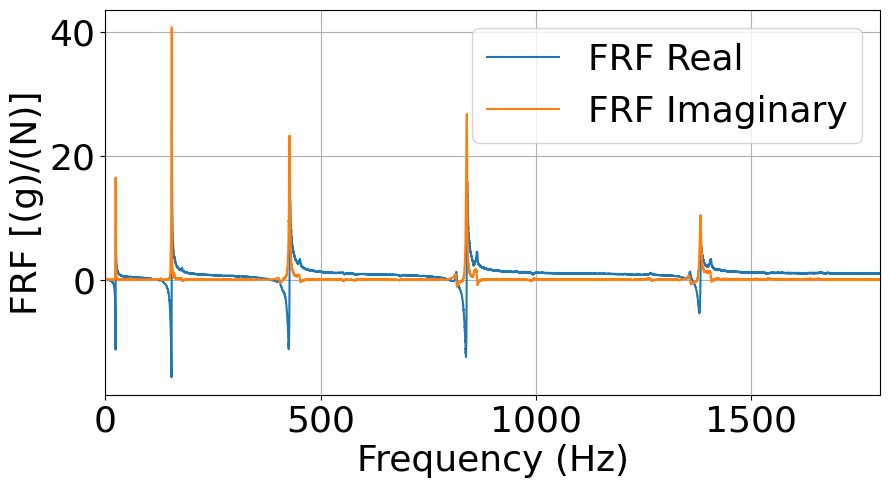

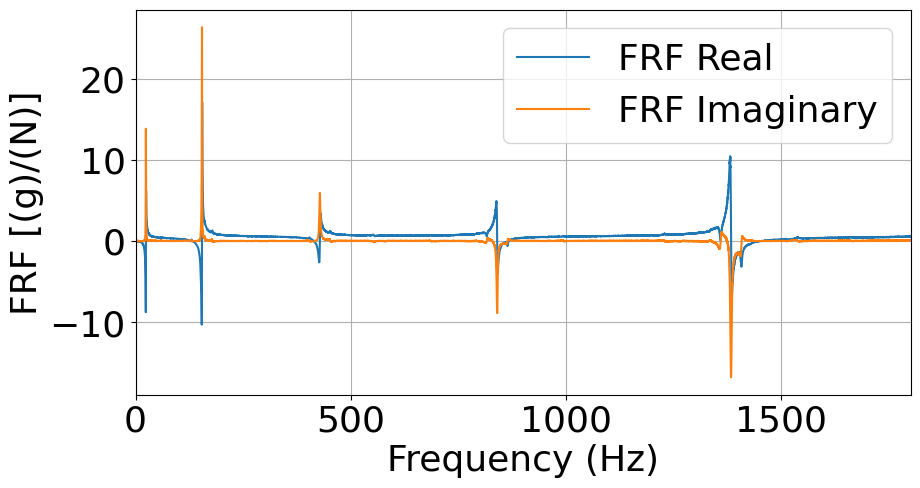

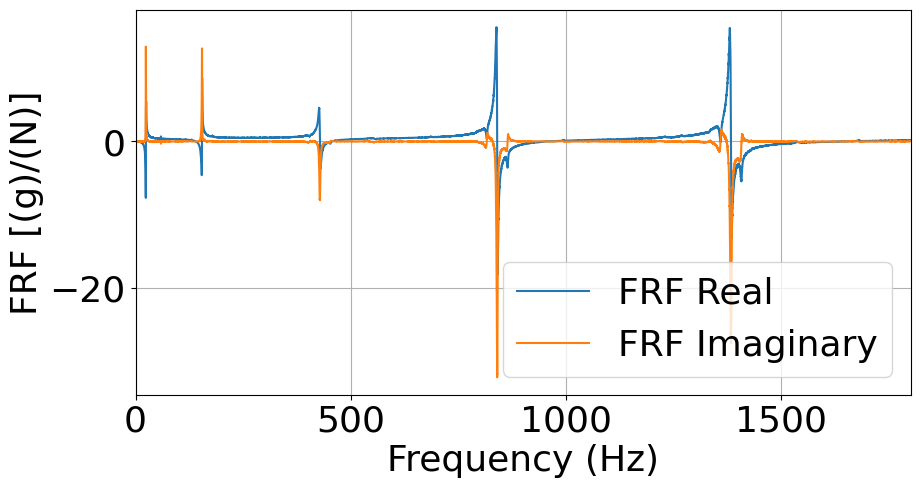

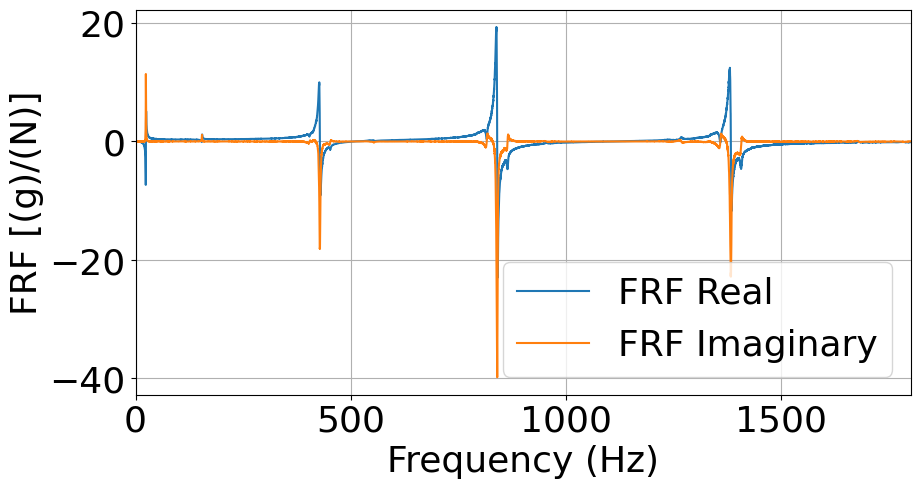

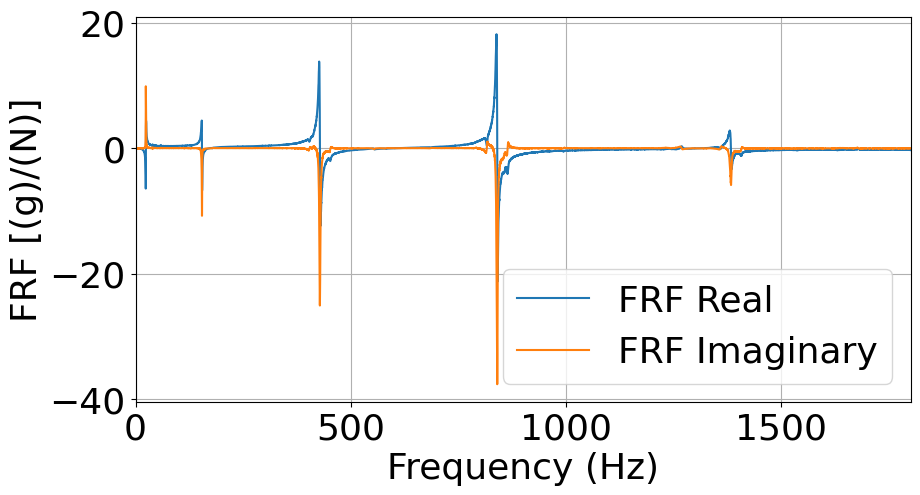

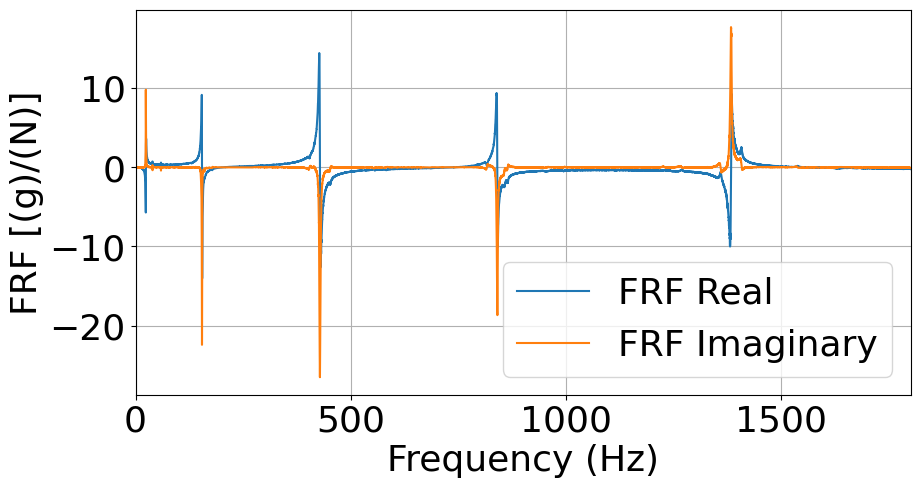

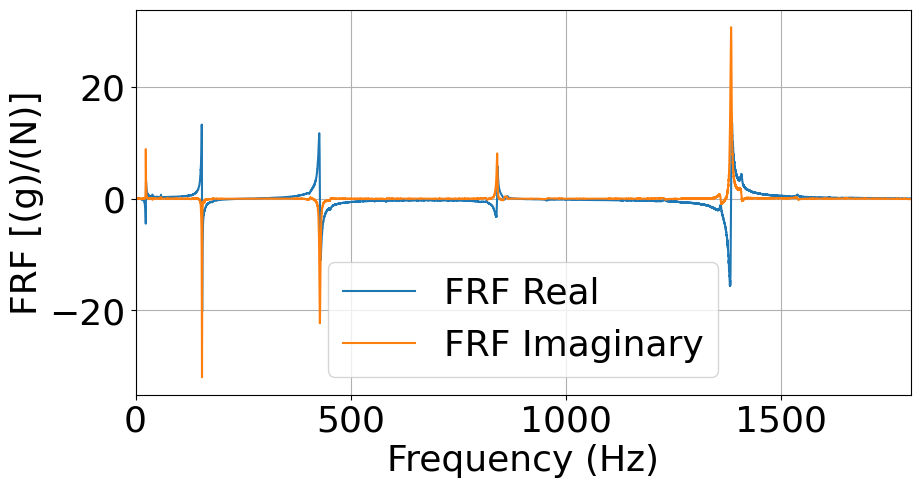

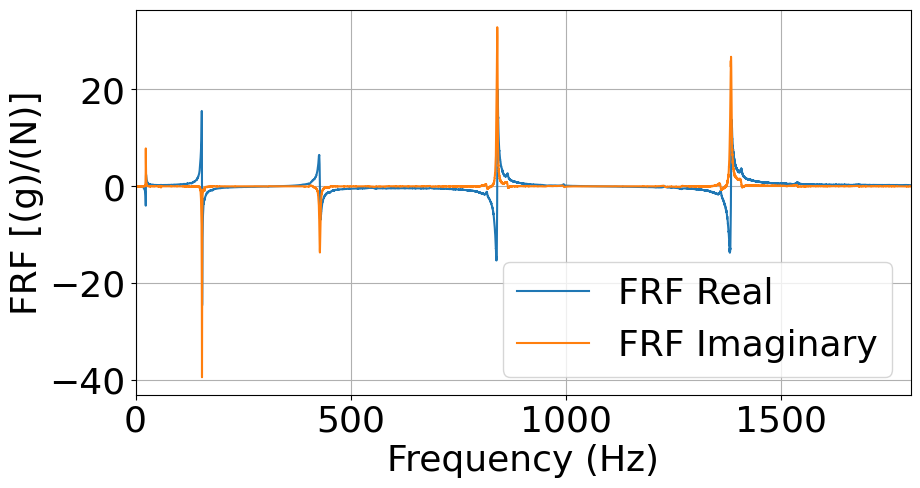

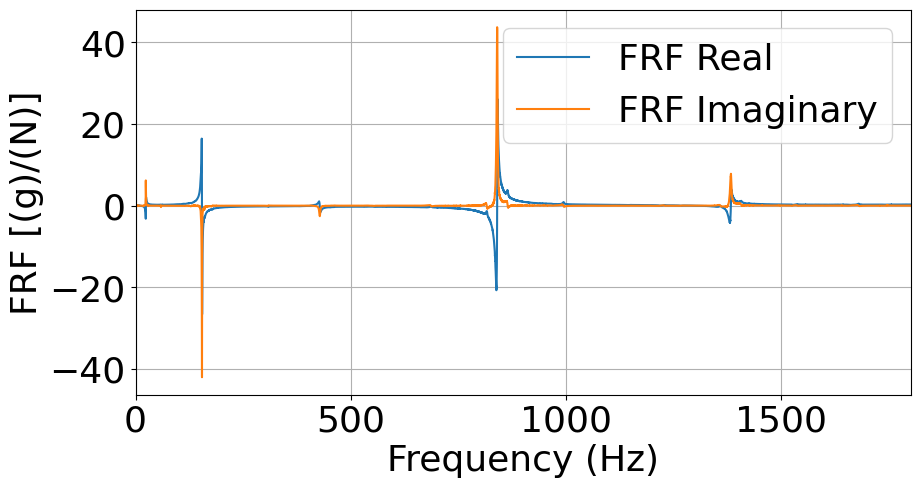

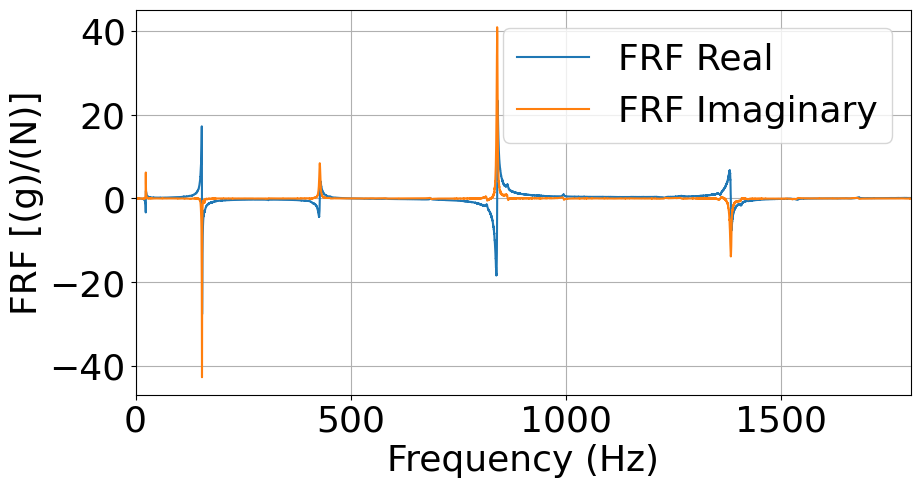

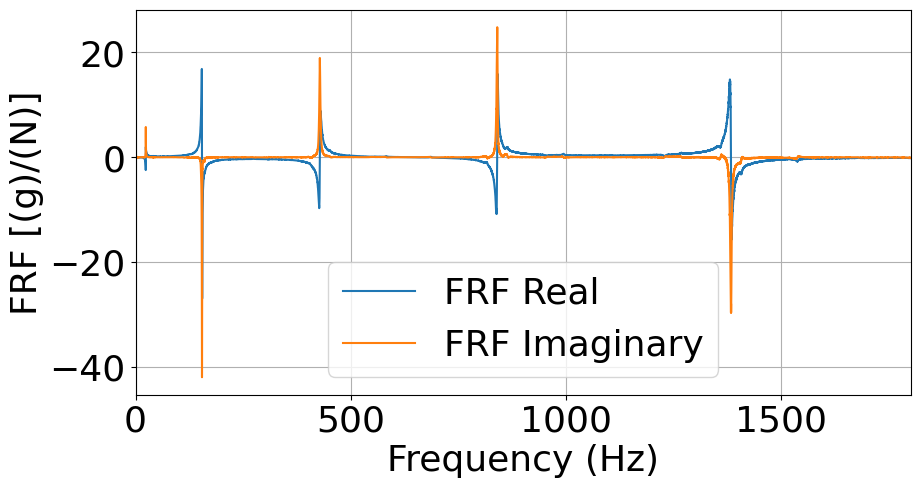

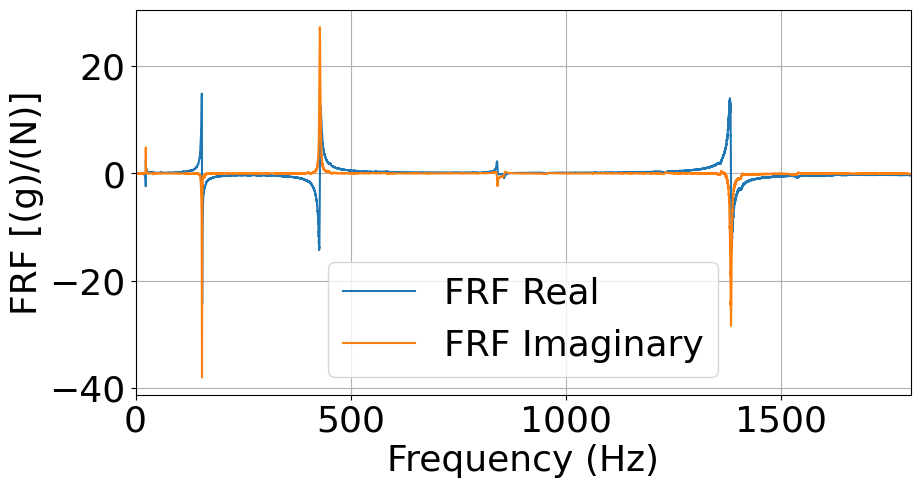

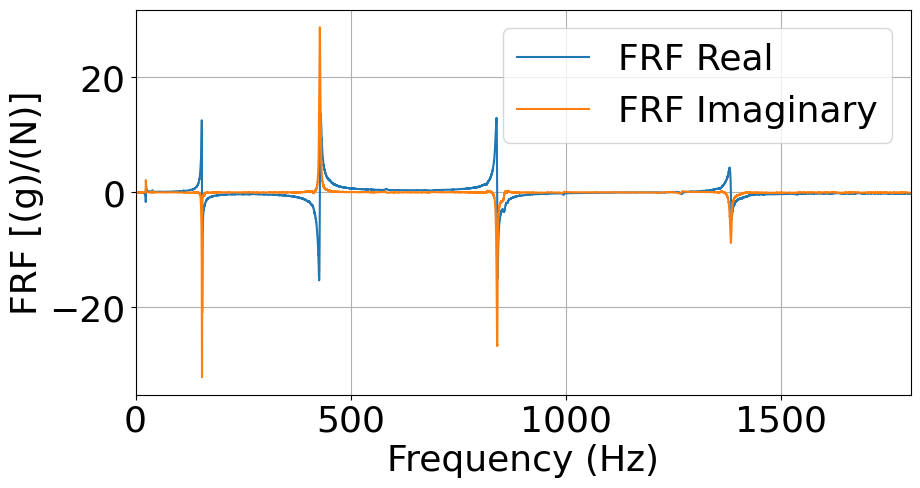

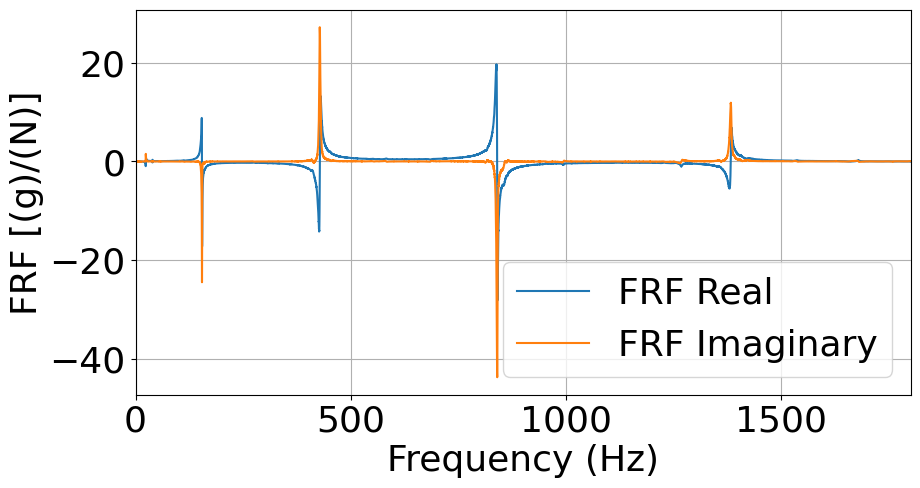

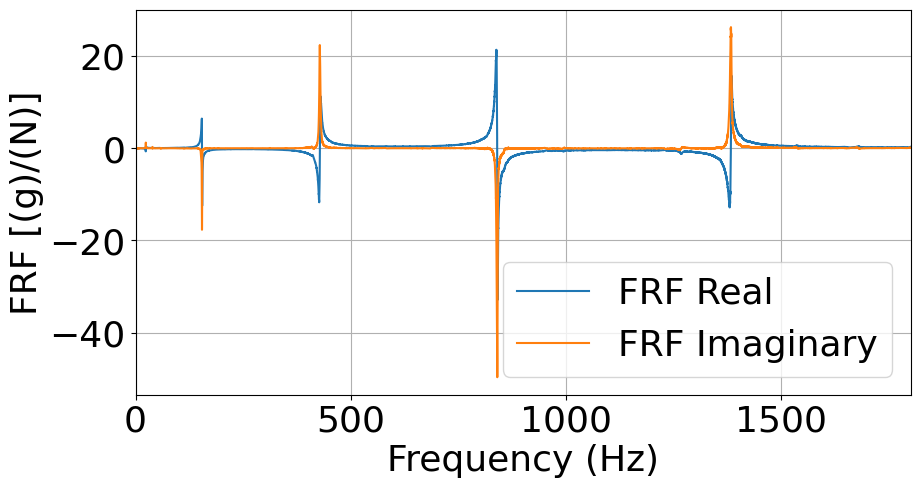

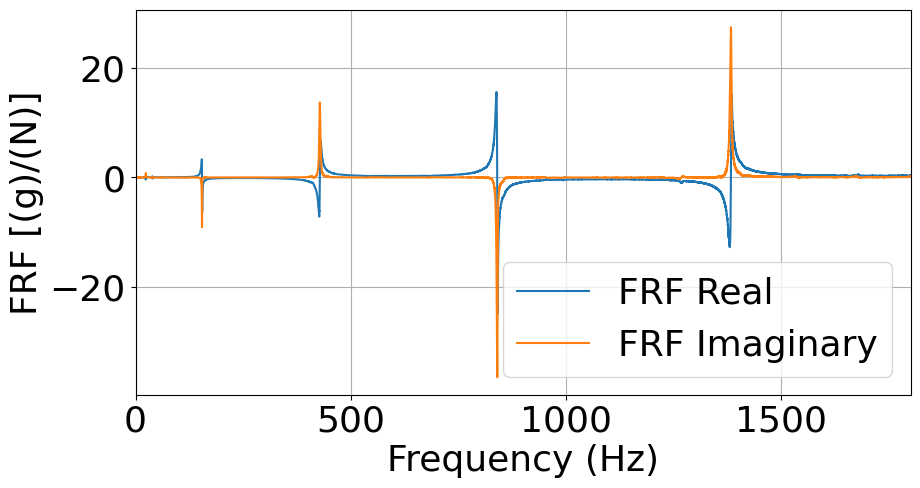

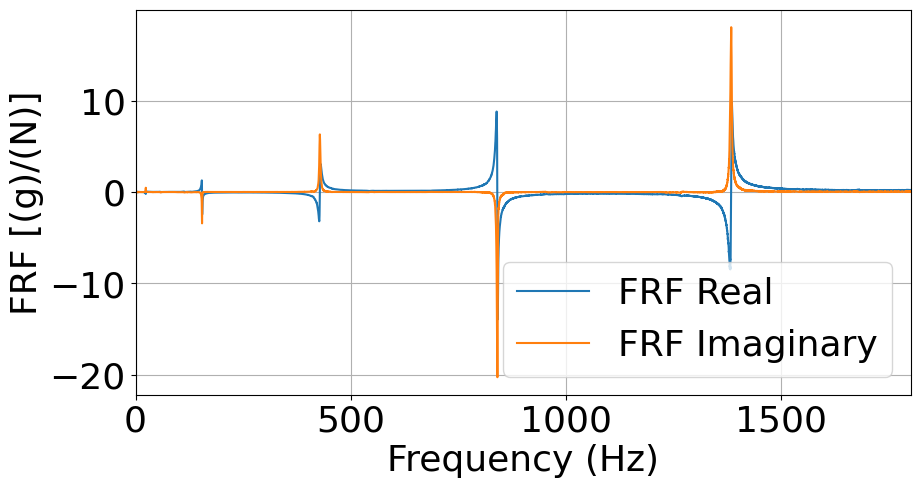

In [72]:
for i, d in enumerate(data, start=1):
    freq, real, imag = restrict_band(d["freq_frf"], d["frf_real"], d["frf_imag"])

    plt.figure(figsize=(10, 5))
    plt.plot(freq, real, label="FRF Real")
    plt.plot(freq, imag, label="FRF Imaginary")
    plt.xlim(FREQ_MIN, FREQ_MAX)
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("FRF [(g)/(N)]")
    # plt.title(f"Impact Location {i}")
    plt.legend()
    plt.savefig(f"Impact location {i}.png", dpi = 350, bbox_inches = "tight")
    plt.show()

In [30]:
def imag_peak_real_zero_table(d, min_peak_distance_hz=80, imag_prom_frac=0.03, real_zero_tol_frac=0.05):
    freq, real, imag = restrict_band(d["freq_frf"], d["frf_real"], d["frf_imag"])

    distance = hz_to_samples(freq, min_peak_distance_hz)
    prominence = np.max(np.abs(imag)) * imag_prom_frac
    peaks, _ = find_peaks(np.abs(imag), prominence=prominence, distance=distance)

    real_tol = real_zero_tol_frac * np.max(np.abs(real))

    rows = []
    for p in peaks:
        if abs(real[p]) <= real_tol:
            rows.append({
                "frequency_hz": freq[p],
                "FRF_real": real[p],
                "FRF_imag": imag[p]
            })

    return pd.DataFrame(rows)

In [31]:
problem_1a_tables = []

for i, d in enumerate(data, start=1):
    df = imag_peak_real_zero_table(d)
    df.insert(0, "impact_location", i)
    df.insert(1, "file", d["file"])
    problem_1a_tables.append(df)

table_1a = pd.concat(problem_1a_tables, ignore_index=True)
table_1a

,impact_location,file,frequency_hz,FRF_real,FRF_imag
0,1,SIG0029.csv,24.000,0.712569,16.500763
1,1,SIG0029.csv,1382.625,1.075311,10.407640
2,2,SIG0030.csv,24.000,0.590284,13.831310
3,2,SIG0030.csv,428.250,0.575521,5.881359
4,2,SIG0030.csv,840.000,-0.163607,-8.871787
5,3,SIG0031.csv,24.000,0.700661,12.971129
6,3,SIG0031.csv,1383.000,0.258982,-27.587944
7,4,SIG0032.csv,24.000,0.387872,11.383556
8,5,SIG0033.csv,1383.125,-0.918086,-5.882810
9,6,SIG0034.csv,428.250,0.676595,-26.501640


In [32]:
table_1a.to_csv("problem_1a_imag_peaks_real_zero_table.csv", index=False)
print("Saved: problem_1a_imag_peaks_real_zero_table.csv")

Saved: problem_1a_imag_peaks_real_zero_table.csv


### 1b

In [67]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.size": 26,        # base font
    "axes.titlesize": 26,
    "axes.labelsize": 26,
    "xtick.labelsize": 26,
    "ytick.labelsize": 26,
    "legend.fontsize": 26
})

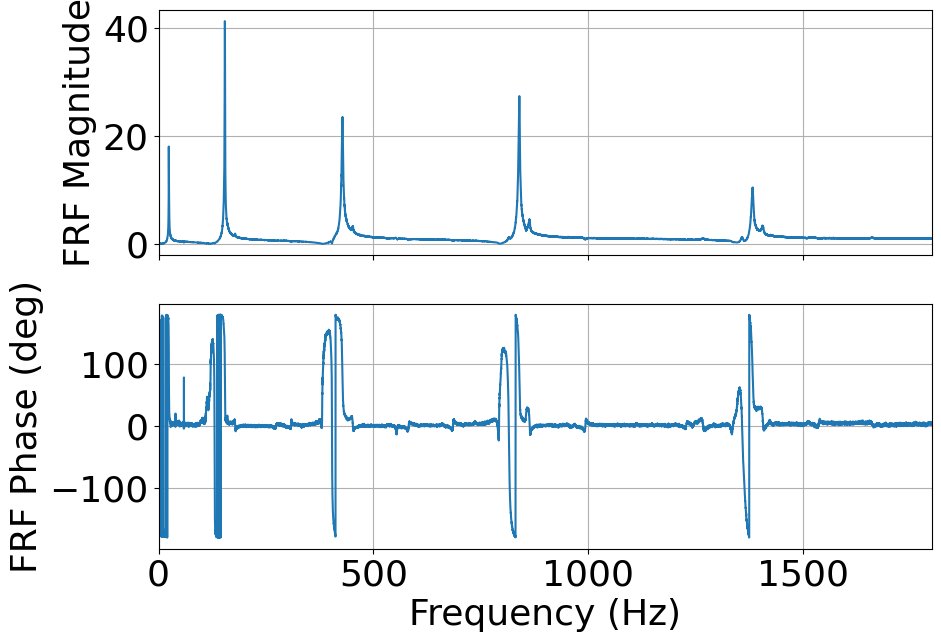

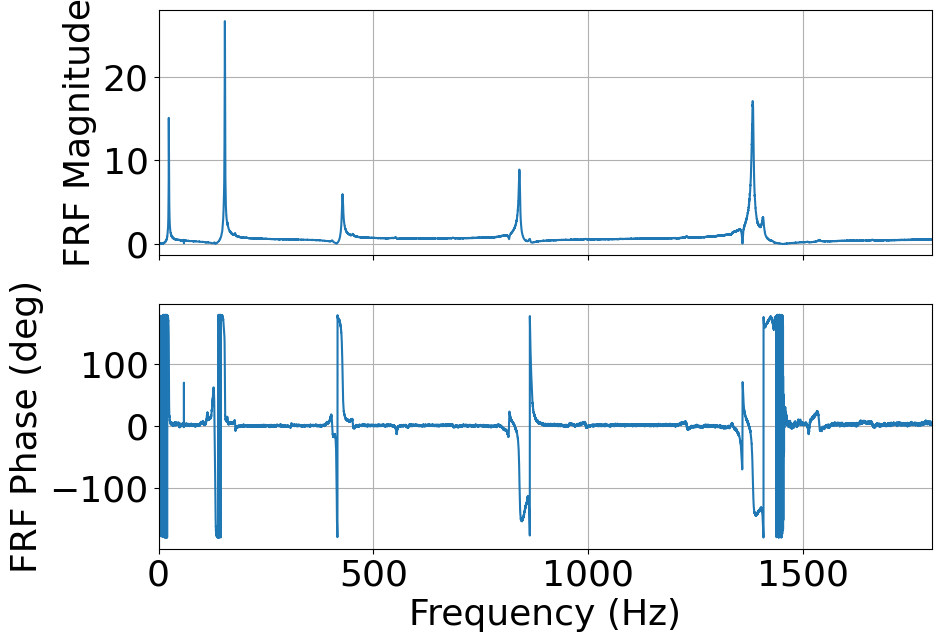

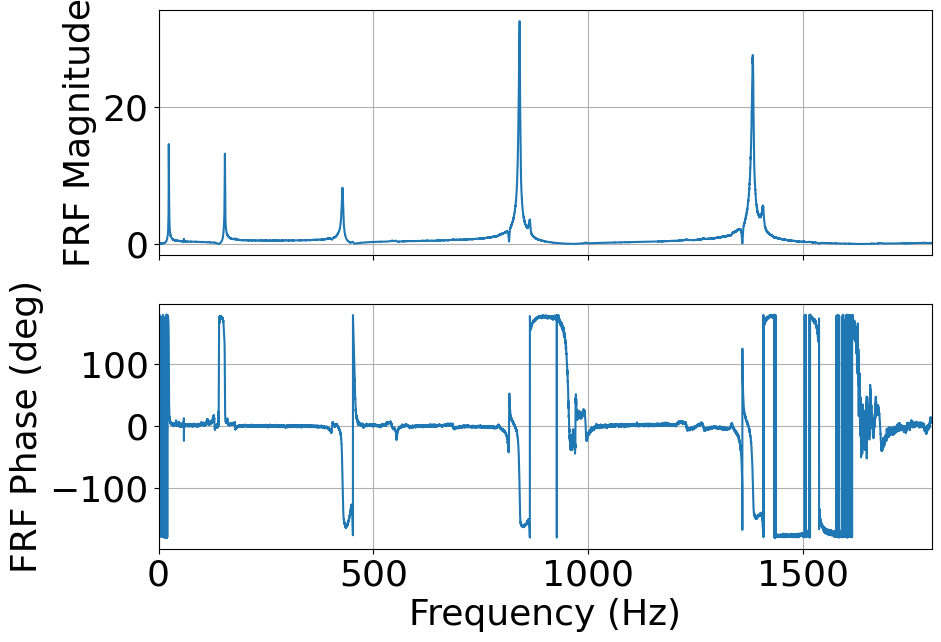

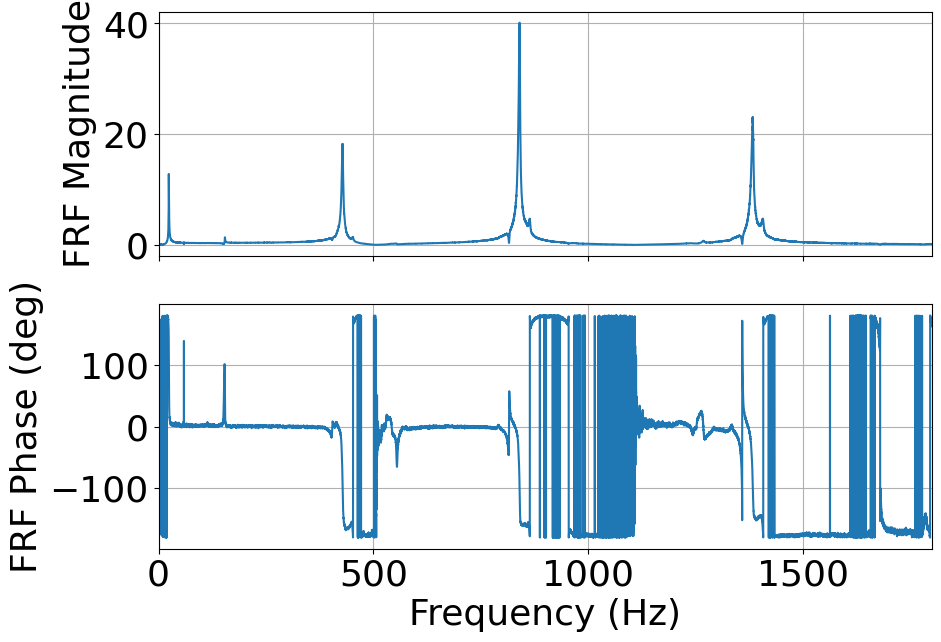

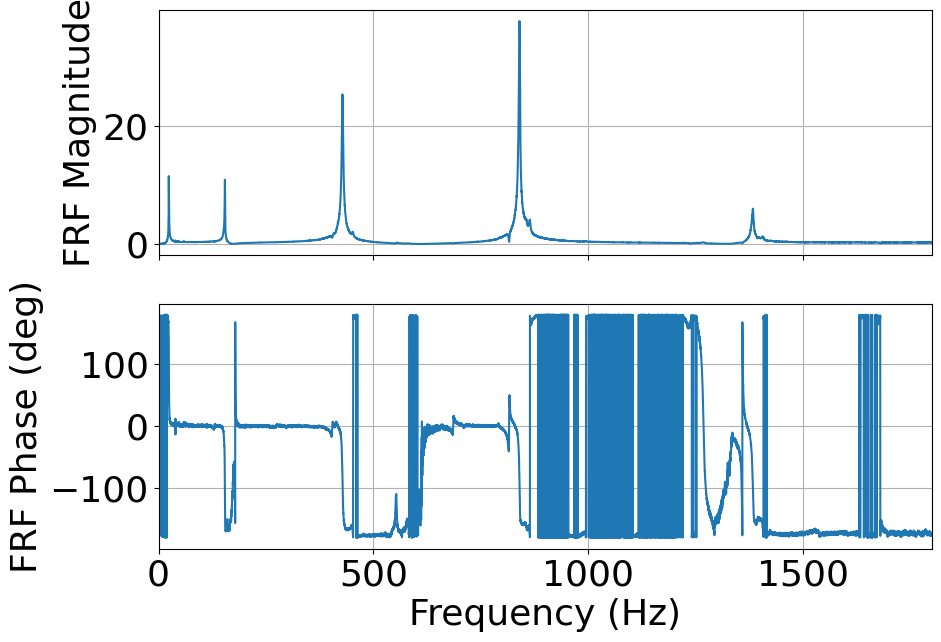

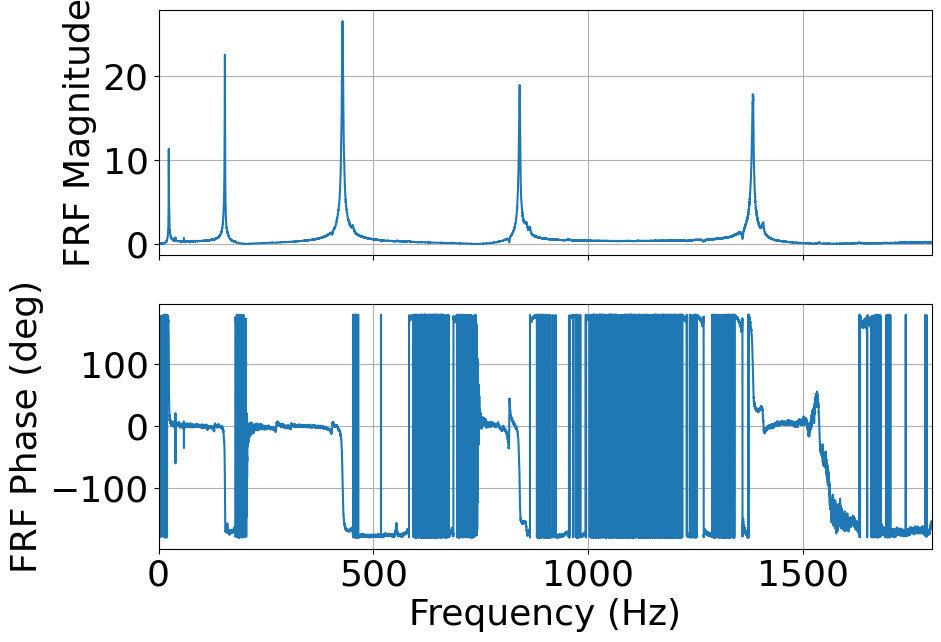

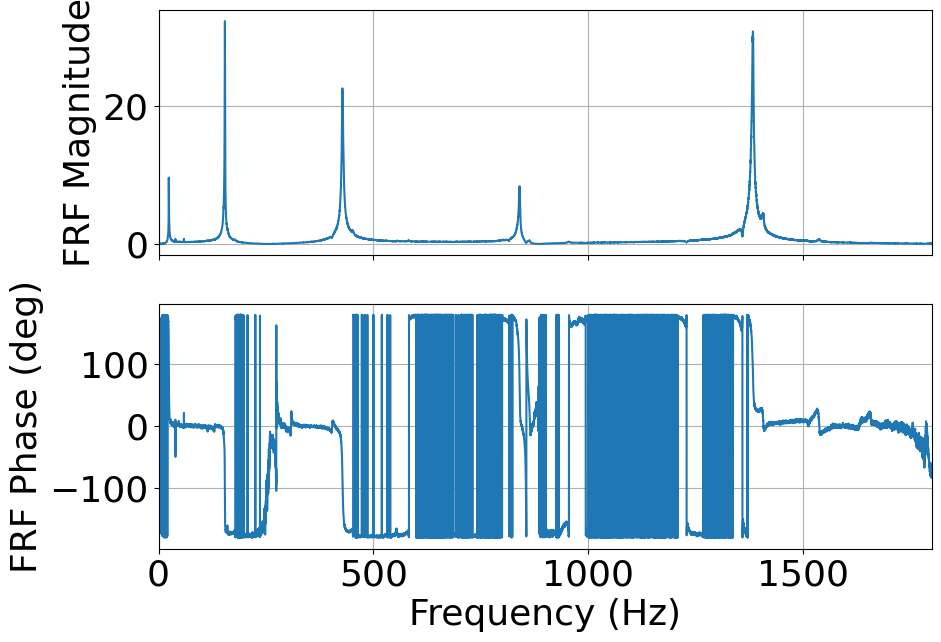

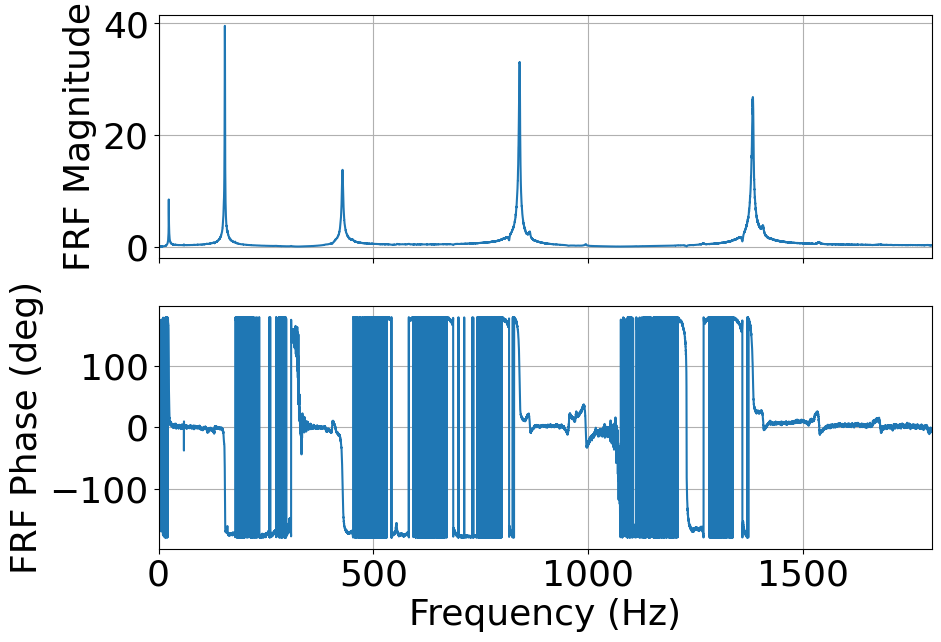

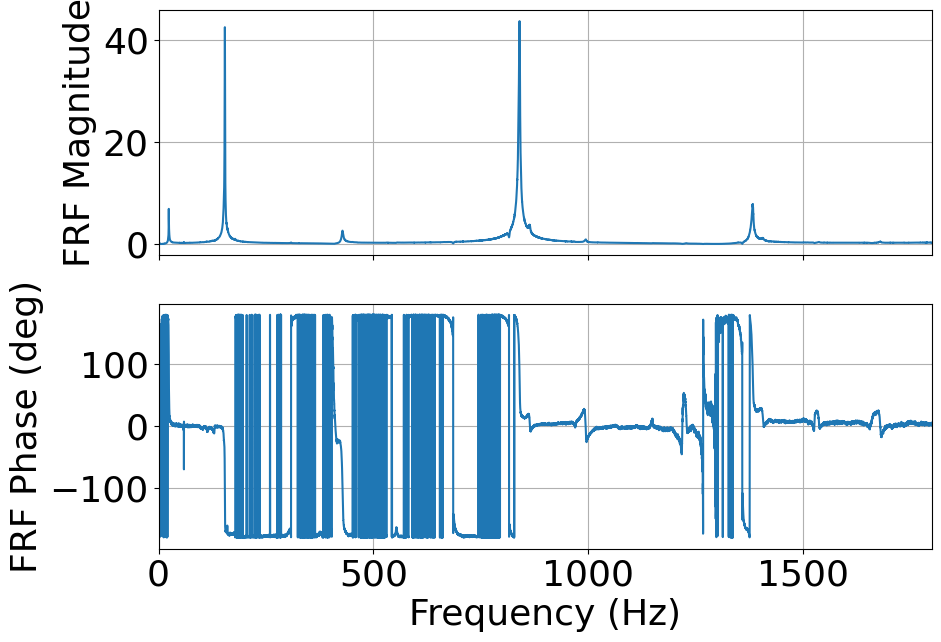

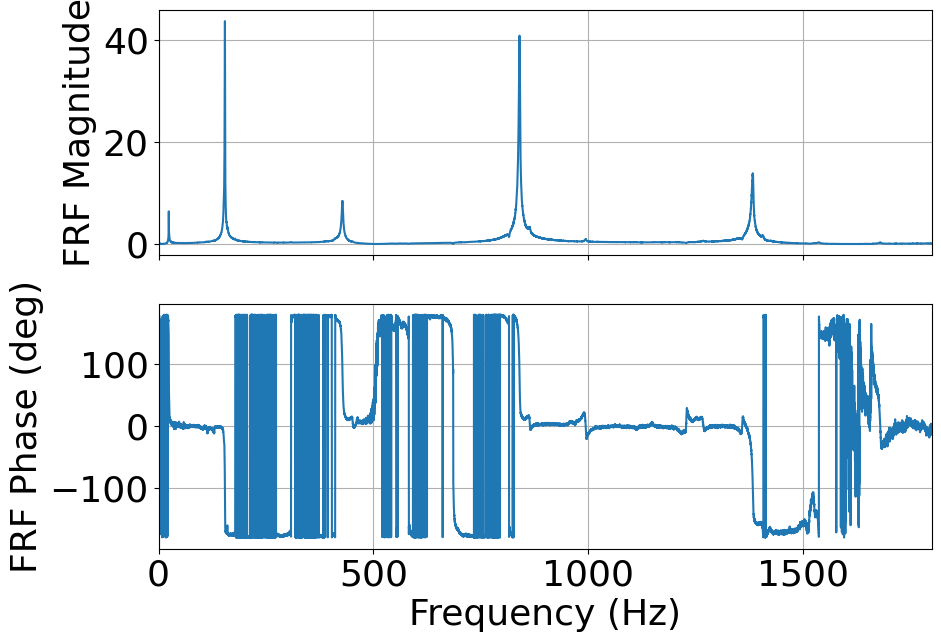

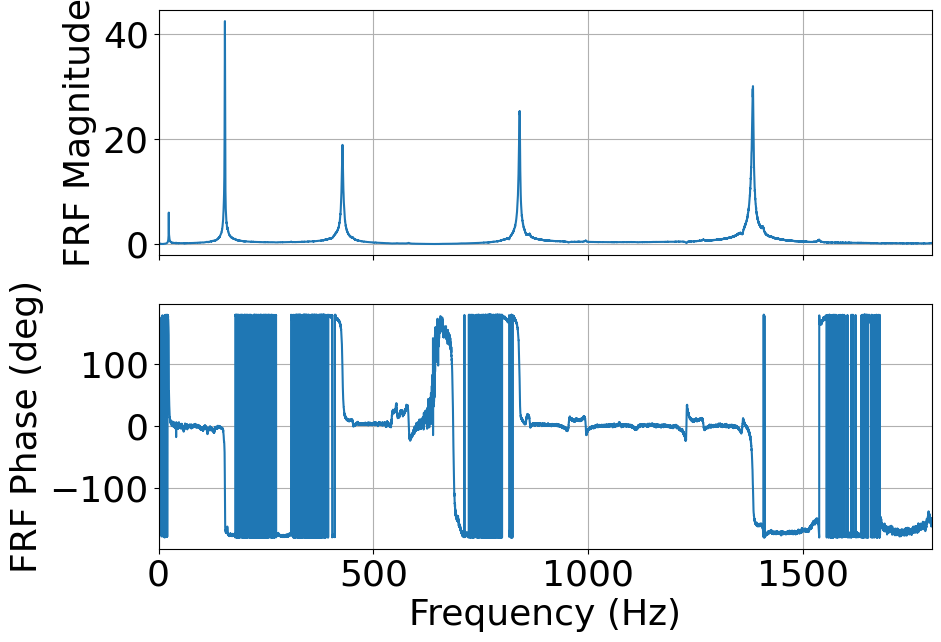

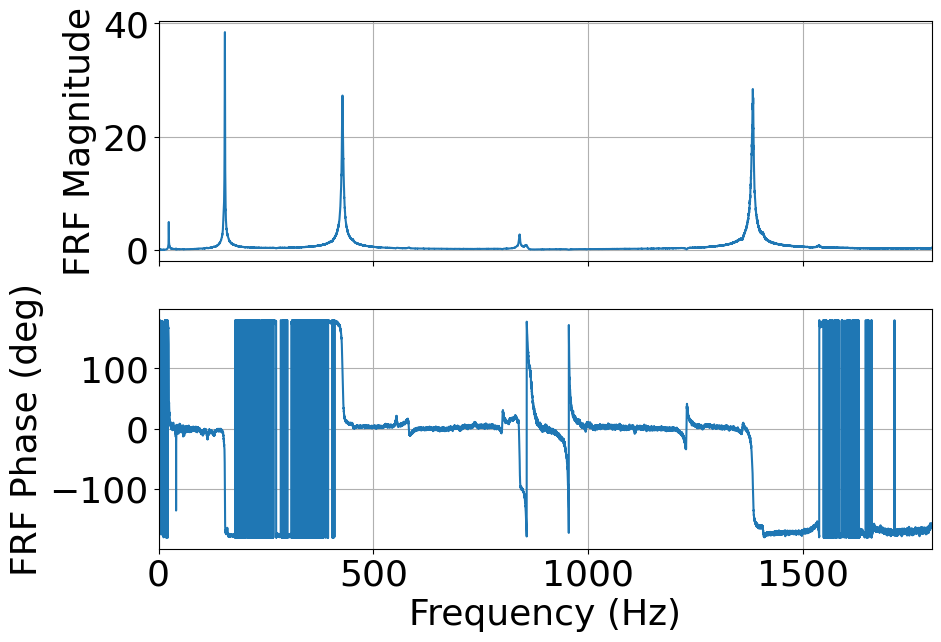

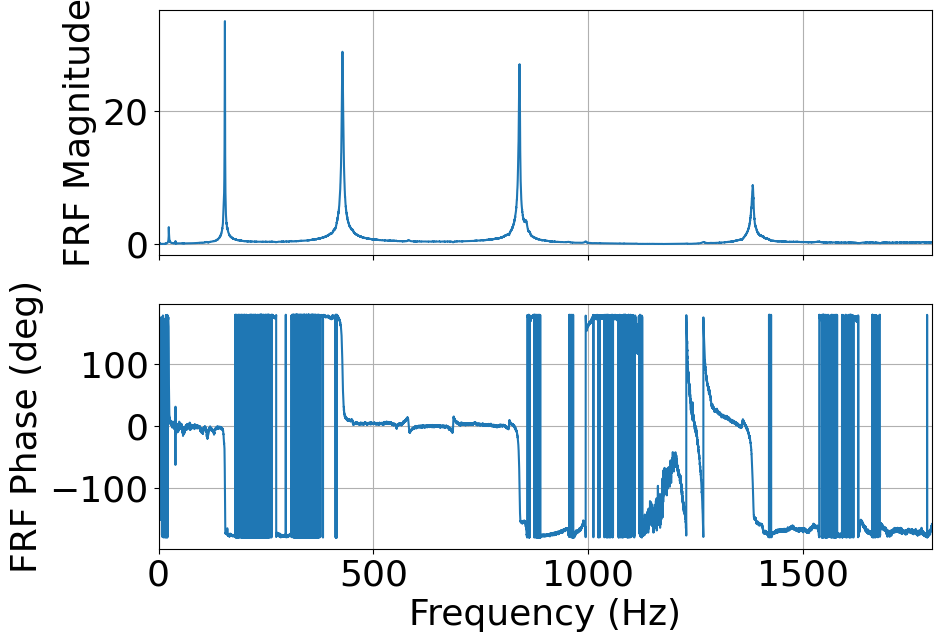

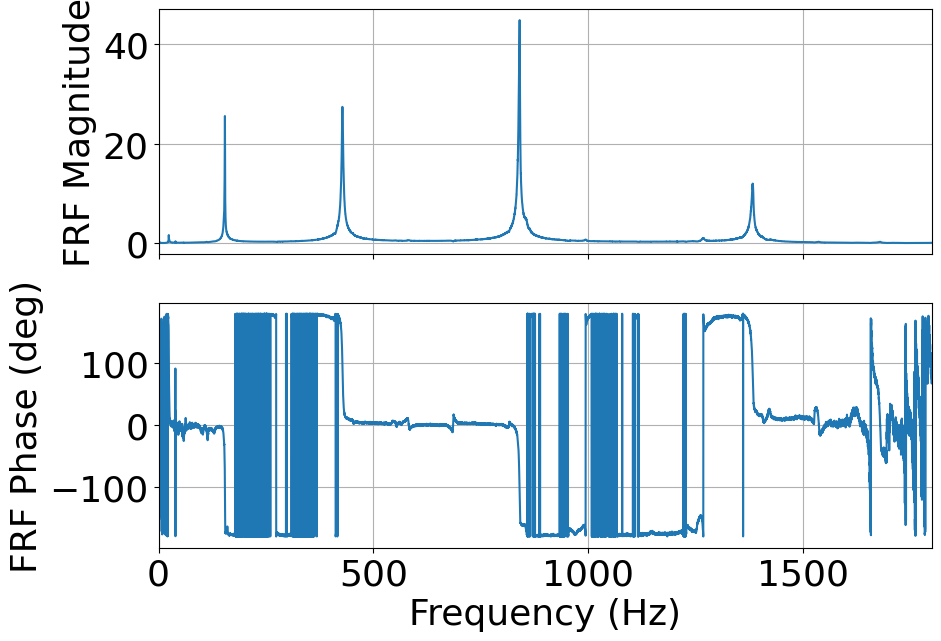

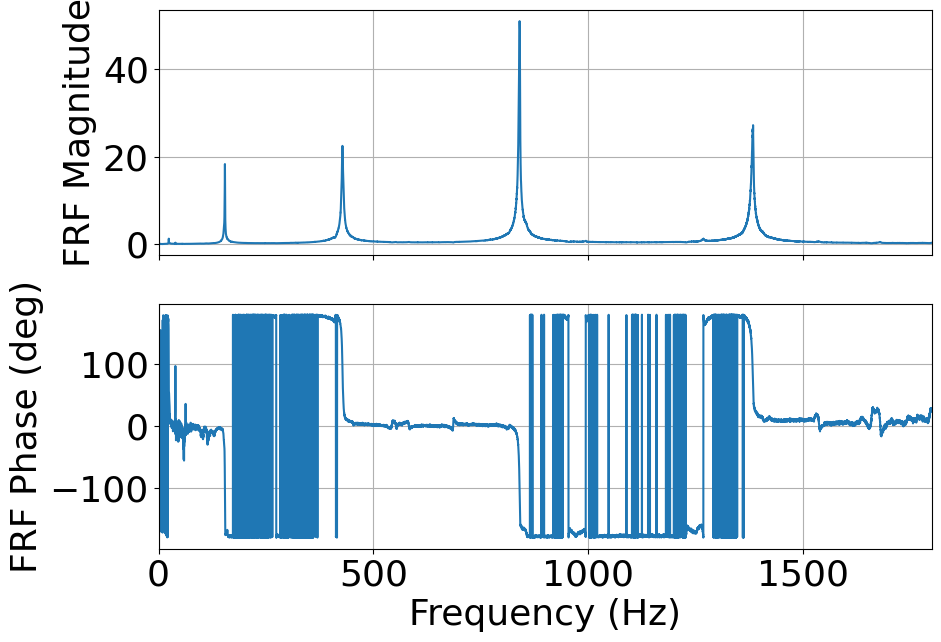

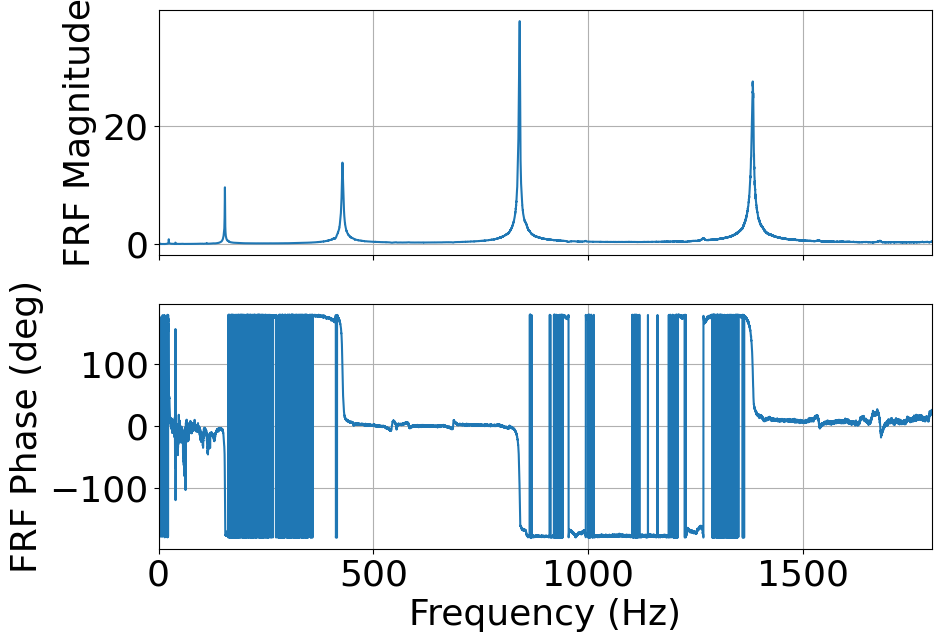

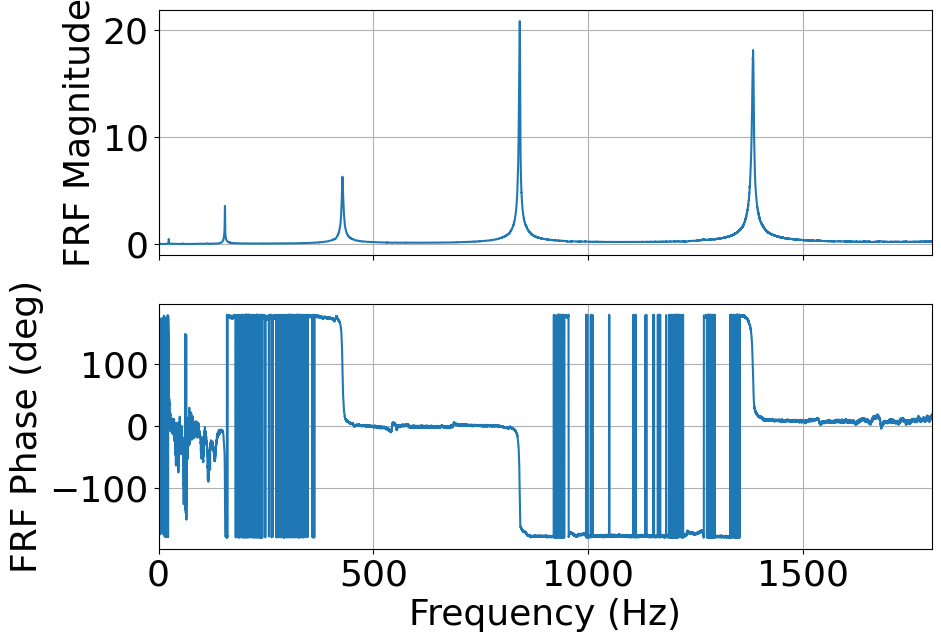

In [73]:
for i, d in enumerate(data, start=1):
    freq, mag, phase = restrict_band(d["freq_frf"], d["frf_mag"], d["frf_phase_deg"])

    fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

    axes[0].plot(freq, mag)
    axes[0].set_ylabel("FRF Magnitude")
    # axes[0].set_title(f"Impact Location {i}")

    axes[1].plot(freq, phase)
    axes[1].set_ylabel("FRF Phase (deg)")
    axes[1].set_xlabel("Frequency (Hz)")
    axes[1].set_xlim(FREQ_MIN, FREQ_MAX)

    plt.tight_layout()
    plt.savefig(f"1b_impact_location_{i}", dpi = 350, bbox_inches = "tight")
    plt.show()

In [58]:
def mag_peak_phase_table(d, min_peak_distance_hz=80, mag_prom_frac=0.03):
    freq, mag, phase = restrict_band(d["freq_frf"], d["frf_mag"], d["frf_phase_deg"])

    distance = hz_to_samples(freq, min_peak_distance_hz)
    prominence = np.max(mag) * mag_prom_frac
    peaks, _ = find_peaks(mag, prominence=prominence, distance=distance)

    df = pd.DataFrame({
        "frequency_hz": freq[peaks],
        "FRF_magnitude": mag[peaks],
        "phase_deg": phase[peaks]
    })

    return df

In [76]:
problem_1b_tables = []

for i, d in enumerate(data, start=1):
    df = mag_peak_phase_table(d)
    df.insert(0, "impact_location", i)
    df.insert(1, "file", d["file"])
    problem_1b_tables.append(df)

table_1b = pd.concat(problem_1b_tables, ignore_index=True)
table_1b

,impact_location,file,frequency_hz,FRF_magnitude,phase_deg
0,1,SIG0029.csv,23.875,18.085501,128.641285
1,1,SIG0029.csv,154.375,41.352942,80.235366
2,1,SIG0029.csv,428.250,23.575044,76.527712
3,1,SIG0029.csv,839.750,27.445667,76.999138
4,1,SIG0029.csv,1382.625,10.463043,84.101165
...,...,...,...,...,...
76,16,SIG0044.csv,1382.875,27.481194,87.986254
77,17,SIG0045.csv,154.625,3.564185,-124.894204
78,17,SIG0045.csv,428.125,6.297692,90.759361
79,17,SIG0045.csv,840.625,20.850020,-105.949354


In [77]:
table_1b.to_csv("problem_1b_mag_peaks_phase_table.csv", index=False)
print("Saved: problem_1b_mag_peaks_phase_table.csv")

Saved: problem_1b_mag_peaks_phase_table.csv


### 1c, 1d, 1e

In [37]:
# Representative frequencies from part (a)
freqs_a = np.sort(table_1a["frequency_hz"].dropna().unique())

# Representative frequencies from part (b)
freqs_b = np.sort(table_1b["frequency_hz"].dropna().unique())

print("Unique frequencies from 1(a):")
print(freqs_a)

print("\nUnique frequencies from 1(b):")
print(freqs_b)

Unique frequencies from 1(a):
[  23.875   24.     154.375  427.875  428.     428.125  428.25   839.875
  840.     840.625 1382.625 1382.75  1382.875 1383.    1383.125]

Unique frequencies from 1(b):
[  23.875  154.375  154.5    154.625  427.875  428.     428.125  428.25
  428.375  839.75   839.875  840.125  840.25   840.375  840.5    840.625
 1382.625 1382.75  1382.875 1383.    1383.125 1383.25  1383.375 1383.625]


In [38]:
def cluster_frequencies(freqs, tol_hz=25):
    freqs = np.sort(np.array(freqs, dtype=float))
    if len(freqs) == 0:
        return np.array([])

    clusters = [[freqs[0]]]
    for f in freqs[1:]:
        if abs(f - np.mean(clusters[-1])) <= tol_hz:
            clusters[-1].append(f)
        else:
            clusters.append([f])

    return np.array([np.median(c) for c in clusters])

clustered_a = cluster_frequencies(table_1a["frequency_hz"].dropna(), tol_hz=25)
clustered_b = cluster_frequencies(table_1b["frequency_hz"].dropna(), tol_hz=25)

print("Clustered frequencies from 1(a):", clustered_a)
print("Clustered frequencies from 1(b):", clustered_b)

Clustered frequencies from 1(a): [  24.      154.375   428.0625  839.9375 1382.875 ]
Clustered frequencies from 1(b): [  23.875  154.5    428.125  840.375 1383.   ]


identified modal frequencies:
mode 1: 23.875 hz
mode 2: 154.500 hz
mode 3: 428.125 hz
mode 4: 840.125 hz
mode 5: 1383.000 hz


/var/folders/7r/rmdh0s294rv5h7t_xljgqnwr0000gp/T/ipykernel_13414/2187935570.py:62: RuntimeWarning: Mean of empty slice
  avg_mag = np.nanmean(mag_stack, axis=0)


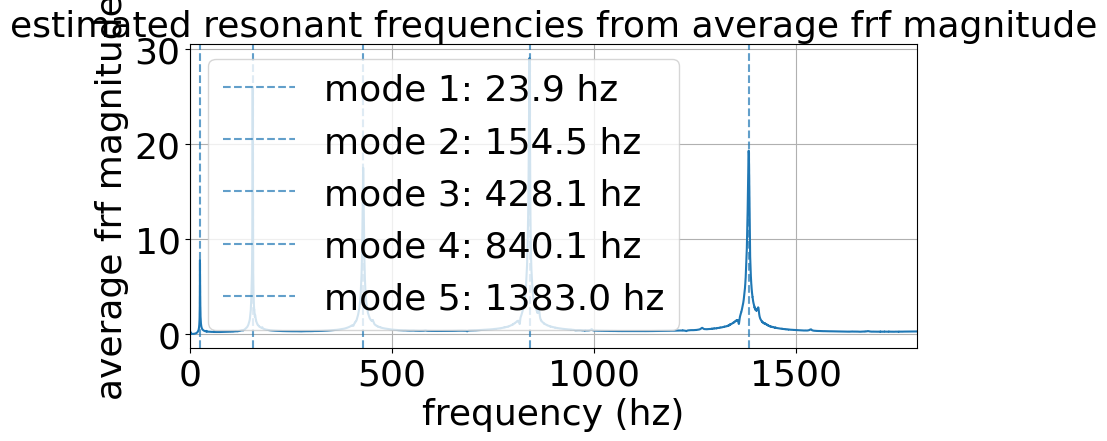


mode 1 (target ≈ 23.875 hz)
location   picked freq   imag peak   normalized
   1       24.000     16.5008       1.0000
   2       24.000     13.8313       0.8382
   3       24.000     12.9711       0.7861
   4       24.000     11.3836       0.6899
   5       23.875      9.8549       0.5972
   6       23.875      9.7857       0.5930
   7       23.875      8.8650       0.5373
   8       23.875      7.8245       0.4742
   9       23.875      6.1805       0.3746
  10       23.875      6.1848       0.3748
  11       23.875      5.7583       0.3490
  12       23.875      4.8398       0.2933
  13       23.875      2.1351       0.1294
  14       23.875      1.5298       0.0927
  15       23.875      1.2223       0.0741
  16       23.875      0.8006       0.0485
  17       23.875      0.4654       0.0282


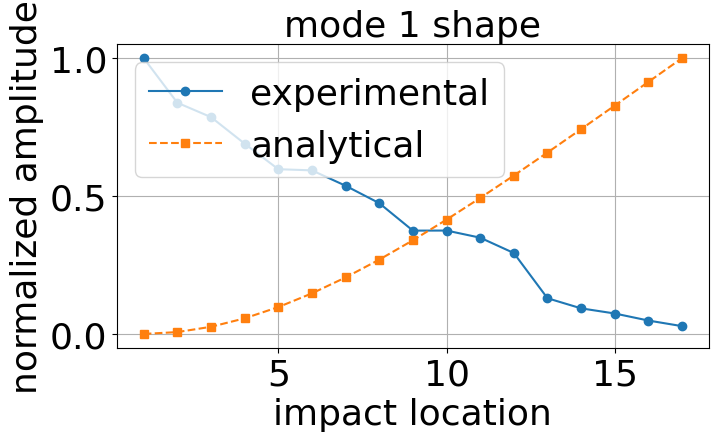


mode 2 (target ≈ 154.500 hz)
location   picked freq   imag peak   normalized
   1      154.375     40.7539      -0.9561
   2      154.375     26.3309      -0.6178
   3      154.375     12.7232      -0.2985
   4      154.375      1.1285      -0.0265
   5      154.375    -10.7836       0.2530
   6      154.375    -22.4103       0.5258
   7      154.375    -31.9676       0.7500
   8      154.375    -39.4109       0.9246
   9      154.375    -42.0161       0.9858
  10      154.375    -42.6231       1.0000
  11      154.375    -41.9171       0.9834
  12      154.375    -37.9638       0.8907
  13      154.375    -32.1442       0.7541
  14      154.375    -24.4605       0.5739
  15      154.375    -17.6916       0.4151
  16      154.375     -9.0978       0.2134
  17      154.500     -3.4267       0.0804


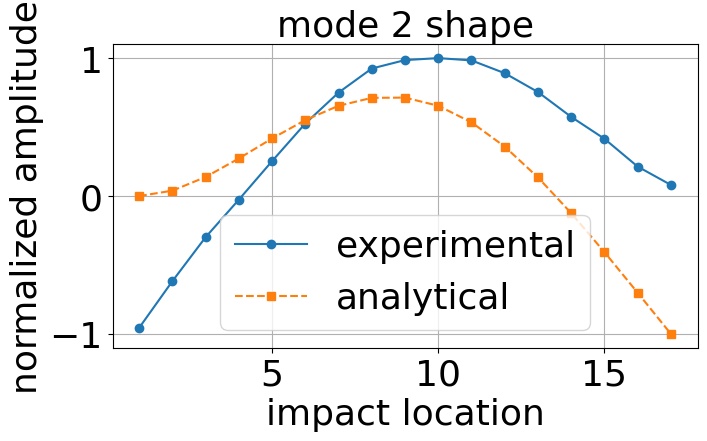


mode 3 (target ≈ 428.125 hz)
location   picked freq   imag peak   normalized
   1      428.000     23.2279      -0.8090
   2      428.125      5.8532      -0.2039
   3      428.125     -7.8203       0.2724
   4      428.125    -17.9550       0.6253
   5      428.125    -25.0869       0.8737
   6      428.250    -26.5016       0.9230
   7      428.125    -22.3045       0.7768
   8      428.250    -13.6627       0.4759
   9      428.000     -2.5745       0.0897
  10      427.875      8.3940      -0.2924
  11      428.125     18.9121      -0.6587
  12      428.125     27.2328      -0.9485
  13      428.000     28.7121      -1.0000
  14      428.125     26.9801      -0.9397
  15      428.000     22.3878      -0.7797
  16      428.000     13.7222      -0.4779
  17      428.125      6.2971      -0.2193


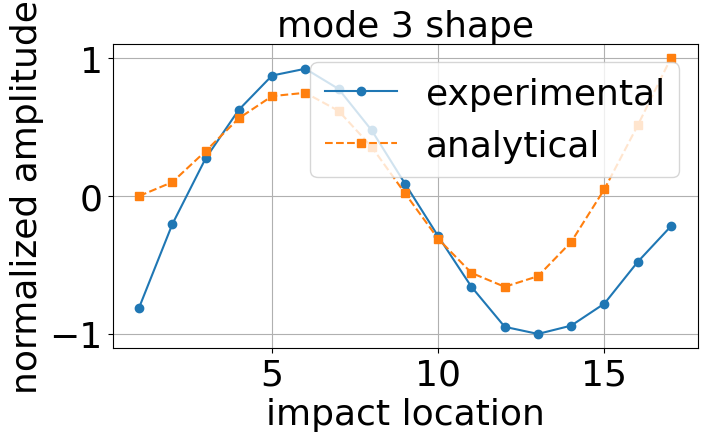


mode 4 (target ≈ 840.125 hz)
location   picked freq   imag peak   normalized
   1      839.625     26.7641      -0.5386
   2      840.000     -8.8718       0.1785
   3      840.125    -31.7661       0.6392
   4      840.125    -39.7847       0.8006
   5      840.125    -37.6315       0.7572
   6      840.250    -18.6628       0.3755
   7      840.000      8.1013      -0.1630
   8      840.125     32.8426      -0.6609
   9      839.875     43.7016      -0.8794
  10      840.125     40.2752      -0.8104
  11      840.125     24.7713      -0.4985
  12      840.625     -2.3409       0.0471
  13      840.125    -25.9174       0.5215
  14      840.125    -43.6895       0.8791
  15      840.250    -49.6959       1.0000
  16      840.125    -36.5329       0.7351
  17      840.500    -20.2486       0.4074


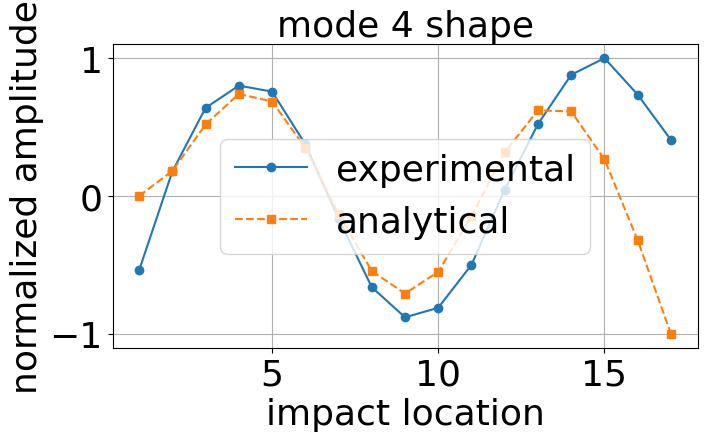


mode 5 (target ≈ 1383.000 hz)
location   picked freq   imag peak   normalized
   1     1383.000     10.1494      -0.3426
   2     1383.125    -16.7708       0.5662
   3     1383.000    -27.5879       0.9313
   4     1383.000    -22.7836       0.7691
   5     1383.000     -5.7722       0.1949
   6     1383.000     17.6788      -0.5968
   7     1382.750     28.1481      -0.9502
   8     1383.125     26.7417      -0.9028
   9     1382.875      7.8093      -0.2636
  10     1382.875    -13.7799       0.4652
  11     1382.875    -29.6224       1.0000
  12     1383.000    -28.4200       0.9594
  13     1383.000     -8.6020       0.2904
  14     1383.000     11.4124      -0.3853
  15     1383.000     26.2620      -0.8866
  16     1383.000     26.5943      -0.8978
  17     1383.125     17.2957      -0.5839


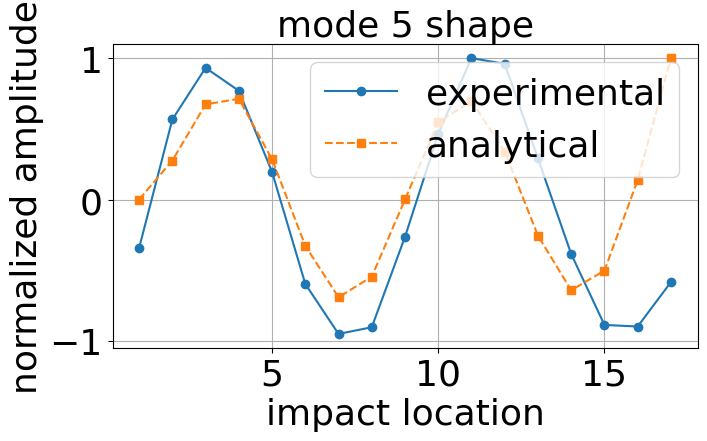

In [91]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

L = 13.0
impact_locations = np.arange(1, 18)
x = np.linspace(0, L, 17)

def cantilever_mode_shape(x, L, lam):
    beta = lam / L
    sigma = (np.cosh(lam) + np.cos(lam)) / (np.sinh(lam) + np.sin(lam))
    return (
        np.cosh(beta * x)
        - np.cos(beta * x)
        - sigma * (np.sinh(beta * x) - np.sin(beta * x))
    )

def normalize_signed(v):
    v = np.asarray(v, dtype=float)
    vmax = np.nanmax(np.abs(v))
    return v / vmax if vmax > 0 else v

def nearest_local_extremum(freq, imag, target_freq, window):
    mask = (freq >= target_freq - window) & (freq <= target_freq + window)
    f_win = freq[mask]
    y_win = imag[mask]

    valid = np.isfinite(f_win) & np.isfinite(y_win)
    f_win = f_win[valid]
    y_win = y_win[valid]

    if len(f_win) < 3:
        return np.nan, np.nan

    peak_idx, _ = find_peaks(y_win)
    trough_idx, _ = find_peaks(-y_win)
    cand_idx = np.sort(np.concatenate([peak_idx, trough_idx]))

    if len(cand_idx) == 0:
        idx = np.argmin(np.abs(f_win - target_freq))
        return f_win[idx], y_win[idx]

    idx = cand_idx[np.argmin(np.abs(f_win[cand_idx] - target_freq))]
    return f_win[idx], y_win[idx]

def estimate_modal_freqs_from_average(data, n_modes=5, fmin=0, fmax=1800):
    freq_ref = np.asarray(data[0]["freq_frf"], dtype=float)
    mag_stack = []

    for d in data:
        freq = np.asarray(d["freq_frf"], dtype=float)
        mag = np.asarray(d["frf_mag"], dtype=float)

        valid = np.isfinite(freq) & np.isfinite(mag)
        freq = freq[valid]
        mag = mag[valid]

        mag_interp = np.interp(freq_ref, freq, mag, left=np.nan, right=np.nan)
        mag_stack.append(mag_interp)

    mag_stack = np.array(mag_stack, dtype=float)
    avg_mag = np.nanmean(mag_stack, axis=0)

    band = (freq_ref >= fmin) & (freq_ref <= fmax)
    freq_band = freq_ref[band]
    avg_band = avg_mag[band]

    valid = np.isfinite(freq_band) & np.isfinite(avg_band)
    freq_band = freq_band[valid]
    avg_band = avg_band[valid]

    peak_idx, props = find_peaks(avg_band, prominence=np.nanmax(avg_band) * 0.03)

    if len(peak_idx) < n_modes:
        peak_idx, props = find_peaks(avg_band)

    prominences = props.get("prominences", np.ones(len(peak_idx)))
    order = np.argsort(prominences)[::-1]
    peak_idx = peak_idx[order]

    chosen = []
    min_sep_hz = 80.0

    for idx in peak_idx:
        f = freq_band[idx]
        if all(abs(f - c) > min_sep_hz for c in chosen):
            chosen.append(f)
        if len(chosen) == n_modes:
            break

    chosen = np.array(sorted(chosen))
    return chosen, freq_band, avg_band

lambdas = {
    1: 1.8751,
    2: 4.6941,
    3: 7.8548,
    4: 10.9955,
    5: 14.1372
}

modal_freq_values, freq_avg, mag_avg = estimate_modal_freqs_from_average(
    data, n_modes=5, fmin=0, fmax=1800
)

modal_freqs = {i + 1: f for i, f in enumerate(modal_freq_values)}

print("identified modal frequencies:")
for mode, f in modal_freqs.items():
    print(f"mode {mode}: {f:.3f} hz")

plt.figure(figsize=(9, 5))
plt.plot(freq_avg, mag_avg)
for mode, f in modal_freqs.items():
    plt.axvline(f, linestyle="--", alpha=0.7, label=f"mode {mode}: {f:.1f} hz")
plt.xlim(0, 1800)
plt.xlabel("frequency (hz)")
plt.ylabel("average frf magnitude")
plt.title("estimated resonant frequencies from average frf magnitude")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

search_window_hz = {1: 25.0, 2: 25.0, 3: 30.0, 4: 35.0, 5: 40.0}

for mode in modal_freqs:
    peak_vals = []
    peak_freqs = []

    for d in data:
        freq = np.asarray(d["freq_frf"], dtype=float)
        imag = np.asarray(d["frf_imag"], dtype=float)

        f_peak, y_peak = nearest_local_extremum(
            freq,
            imag,
            modal_freqs[mode],
            search_window_hz[mode]
        )

        peak_freqs.append(f_peak)
        peak_vals.append(y_peak)

    peak_freqs = np.array(peak_freqs, dtype=float)
    peak_vals = np.array(peak_vals, dtype=float)
    peak_norm = normalize_signed(peak_vals)

    ana = cantilever_mode_shape(x, L, lambdas[mode])
    ana_norm = normalize_signed(ana)

    if np.dot(peak_norm, ana_norm) < 0:
        peak_norm = -peak_norm

    print(f"\nmode {mode} (target ≈ {modal_freqs[mode]:.3f} hz)")
    print("location   picked freq   imag peak   normalized")
    for i in range(17):
        print(
            f"{i+1:>4}   "
            f"{peak_freqs[i]:>10.3f}   "
            f"{peak_vals[i]:>9.4f}   "
            f"{peak_norm[i]:>10.4f}"
        )

    plt.figure(figsize=(8, 5))
    plt.plot(impact_locations, peak_norm, 'o-', label='experimental')
    plt.plot(impact_locations, ana_norm, 's--', label='analytical')
    plt.xlabel("impact location")
    plt.ylabel("normalized amplitude")
    plt.title(f"mode {mode} shape")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [88]:
d["freq_frf"]
d["frf_imag"]

array([ 0.        , -0.0810327 ,  0.01100731, ...,         nan,
               nan,         nan], shape=(32768,))